In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget
from itertools import combinations
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
from scipy.stats import median_abs_deviation
import scanpy.external as sce

import rmm
import cupy as cp
from rmm.allocators.cupy import rmm_cupy_allocator

rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 2

CUDARuntimeError: cudaErrorDevicesUnavailable: CUDA-capable device(s) is/are busy or unavailable

# Load in raw data

In [ ]:
%%time

path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/raw_merged_gene_data.h5ad"

adata_raw = sc.read_h5ad(path)

sc.logging.print_memory_usage() 

print(f"Initial shape: {adata_raw.shape}\n")
print(f"N cells in HYB dataset: {adata_raw[adata_raw.obs['dataset'] == 'Hybrid'].n_obs}")
print(f"N cells in scFib dataset: {adata_raw[adata_raw.obs['dataset'] == 'Control'].n_obs}\n")


### --- Handle HYB cells with NaN feature barcode predictions ---
init_cells_hybrid = adata_raw[adata_raw.obs['dataset'] == 'Hybrid'].n_obs

# remove HYB cells with NaN feature barcode predictions
hybrid_to_remove = (adata_raw.obs['dataset'] == 'Hybrid') & (adata_raw.obs['assigned_condition'].isna())
cells_to_keep = ~(hybrid_to_remove)
adata_raw = adata_raw[cells_to_keep].copy()

final_cells_hybrid = adata_raw[adata_raw.obs['dataset'] == 'Hybrid'].n_obs
removed_hybrid_cells = init_cells_hybrid - final_cells_hybrid

print(f"Removed {removed_hybrid_cells} 'Hybrid' cells with unassigned feature barcodes")



### --- Add new column for grouping HYB cells vs Controls ---
adata_raw.obs['pooled_condition'] = adata_raw.obs['assigned_condition'].replace({
    "G1": "Control",
    "S": "Control",
    "G2M": "Control",
    "PRRX1": "siPRRX1",
    "PRRX1_MYOD": "siPRRX1/mmMYOD1",
    "MYOD": "mmMYOD1"
})

# fill remaining NaN feature barcode predictions (only control cells) with 'Control'
adata_raw.obs['pooled_condition'] = adata_raw.obs['pooled_condition'].fillna('Control')
print(adata_raw.obs['pooled_condition'].value_counts())

print(f"Final shape: {adata_raw.shape}")
adata_raw

# Transfection efficiency

In [3]:
# tdata = adata_raw.copy()

# myod1_expr = tdata[:, 'MYOD1'].X.toarray().flatten()

# init_cells = tdata.n_obs

# remove_siPRRX1 = (tdata.obs['pooled_condition'] == 'siPRRX1') & (myod1_expr > 0)
# remove_mmMYOD1  = (tdata.obs['pooled_condition'] == 'mmMYOD1') & (myod1_expr == 0)
# remove_HYB  = (tdata.obs['pooled_condition'] == 'siPRRX1/mmMYOD1') & (myod1_expr == 0)

# # Combine both masks
# mask_remove = remove_siPRRX1 | remove_mmMYOD1 | remove_HYB

# # Keep only cells not in the mask
# tdata = tdata[~mask_remove].copy()

# # Final cell count
# final_cells = tdata.n_obs
# print(f"Removed {init_cells - final_cells} cells total:")
# print(f"  - {remove_siPRRX1.sum()} siPRRX1 cells with non-zero MYOD1 expression")
# print(f"  - {remove_mmMYOD1.sum()} mmMYOD1 cells with zero MYOD1 expression")
# print(f"  - {remove_HYB.sum()} siPRRX1/mmMYOD1 cells with zero MYOD1 expression")

# print(f"Final cells: {final_cells}")
# print(tdata.obs['pooled_condition'].value_counts())

Removed 1477 cells total:
  - 287 siPRRX1 cells with non-zero MYOD1 expression
  - 258 mmMYOD1 cells with zero MYOD1 expression
  - 932 siPRRX1/mmMYOD1 cells with zero MYOD1 expression
Final cells: 18380
pooled_condition
Control            8963
siPRRX1            3668
siPRRX1/mmMYOD1    3242
mmMYOD1            2507
Name: count, dtype: int64


In [18]:
# gene = 'PRRX1'
# prrx1_idx = tdata.var_names.get_loc(gene)

# # 2. Extract the PRRX1 column from the sparse matrix (returns a 2D sparse matrix)
# prrx1_values = tdata.X[:, prrx1_idx].toarray().ravel()  # convert to 1D np array

# # 3. Build the dataframe
# df = pd.DataFrame({
#     gene: prrx1_values,
#     'pooled_condition': tdata.obs['pooled_condition'].values
# }, index=tdata.obs_names)

# df.head()

,PRRX1,pooled_condition
AAACCAAAGCAACTGC_hybrid,0.0,siPRRX1/mmMYOD1
AAACCAAAGTAGCCGT_hybrid,0.0,siPRRX1/mmMYOD1
AAACCAAAGTAGGGCA_hybrid,1.0,mmMYOD1
AAACCAAAGTCTAGGC_hybrid,1.0,siPRRX1/mmMYOD1
AAACCATTCACGTAAT_hybrid,0.0,siPRRX1


In [19]:
# df.groupby('pooled_condition', observed=True)[gene].describe()

,count,mean,std,min,25%,50%,75%,max
pooled_condition,,,,,,,,
Control,8963.0,2.110008,2.237303,0.0,0.0,2.0,3.0,17.0
mmMYOD1,2507.0,1.083367,1.607243,0.0,0.0,0.0,2.0,15.0
siPRRX1,3668.0,0.703381,1.132517,0.0,0.0,0.0,1.0,10.0
siPRRX1/mmMYOD1,3242.0,0.427205,0.922368,0.0,0.0,0.0,1.0,11.0


In [13]:
# # how many cells with PRRX1 counts less than median in Control
# groups = ['Control', 'mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1']

# for g in groups:
#     tmp = df[df['pooled_condition'] == g]
    
#     print(f"{g}:")
#     print(f"\t N cells with PRRX1 counts less than control median: {tmp[tmp['PRRX1'] < 2.0].shape[0]}")
#     print(f"\t N cells with PRRX1 counts greater (or =) than control median: {tmp[tmp['PRRX1'] >= 2.0].shape[0]}")
#     print(f"\t N cells with 0 PRRX1 counts: {tmp[tmp['PRRX1'] == 0].shape[0]}")

Control:
	 N cells with PRRX1 counts less than control median: 4392
	 N cells with PRRX1 counts greater (or =) than control median: 4571
	 N cells with 0 PRRX1 counts: 2741
mmMYOD1:
	 N cells with PRRX1 counts less than control median: 1836
	 N cells with PRRX1 counts greater (or =) than control median: 671
	 N cells with 0 PRRX1 counts: 1265
siPRRX1:
	 N cells with PRRX1 counts less than control median: 3029
	 N cells with PRRX1 counts greater (or =) than control median: 639
	 N cells with 0 PRRX1 counts: 2207
siPRRX1/mmMYOD1:
	 N cells with PRRX1 counts less than control median: 2930
	 N cells with PRRX1 counts greater (or =) than control median: 312
	 N cells with 0 PRRX1 counts: 2402


# Remove unwanted cells

Removing cells from siPRRX1 only condition with positive MYOD1 expression 
<br>
Removing cells from mmMYOD1 only condition with zero MYOD1 expression

In [3]:
# # Extract MYOD1 expression as a dense 1D array
# myod1_expr = adata_raw[:, 'MYOD1'].X.toarray().flatten()

# # Initial number of cells
# init_cells = adata_raw.n_obs

# ### Create exclusion masks
# # Remove siPRRX1 cells with positive MYOD expression
# remove_siPRRX1 = (adata_raw.obs['pooled_condition'] == 'siPRRX1') & (myod1_expr > 0)

# # Remove mmMYOD1 cells with zero MYOD expression
# remove_mmMYOD1  = (adata_raw.obs['pooled_condition'] == 'mmMYOD1') & (myod1_expr == 0)

# # # Remove HYB cells with zero MYOD expression
# # remove_HYB  = (adata_raw.obs['pooled_condition'] == 'siPRRX1/mmMYOD1') & (myod1_expr == 0)

# # Combine both masks
# mask_remove = remove_siPRRX1 | remove_mmMYOD1 # | remove_HYB

# # Keep only cells not in the mask
# adata_raw = adata_raw[~mask_remove].copy()

# # Final cell count
# final_cells = adata_raw.n_obs
# print(f"Removed {init_cells - final_cells} cells total:")
# print(f"  - {remove_siPRRX1.sum()} siPRRX1 cells with non-zero MYOD1 expression")
# print(f"  - {remove_mmMYOD1.sum()} mmMYOD1 cells with zero MYOD1 expression")
# # print(f"  - {remove_HYB.sum()} siPRRX1/mmMYOD1 cells with zero MYOD1 expression")

# print(f"Final cells: {final_cells}")
# print(adata_raw.obs['pooled_condition'].value_counts())

Removed 545 cells total:
  - 287 siPRRX1 cells with non-zero MYOD1 expression
  - 258 mmMYOD1 cells with zero MYOD1 expression
Final cells: 19312
pooled_condition
Control            8963
siPRRX1/mmMYOD1    4174
siPRRX1            3668
mmMYOD1            2507
Name: count, dtype: int64


# QC and filtering

In [ ]:
adata = adata_raw.copy()

# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True, log1p=True)

plt.rcdefaults()
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    groupby='dataset',
)

## MAD filtering of low quality cells

MAD = Median absolute deviation

In [ ]:
# Identify outlier cells with MADs per dataset
def is_outlier_by_group(adata, metric: str, nmads: int, group_col: str = 'dataset'):
    outlier_series = pd.Series(False, index=adata.obs.index)
    unique_groups = adata.obs[group_col].unique()

    for group in unique_groups:
        group_mask = (adata.obs[group_col] == group)
        M_group = adata.obs.loc[group_mask, metric]

        if len(M_group) < 2 or M_group.isnull().all():
            continue

        median_val_group = np.median(M_group)
        mad_val_group = median_abs_deviation(M_group)

        if mad_val_group == 0:
            continue

        outliers_in_group = (M_group < median_val_group - nmads * mad_val_group) | \
                            (median_val_group + nmads * mad_val_group < M_group)

        outlier_series.loc[group_mask] = outliers_in_group

    return outlier_series

### determine outliers
adata.obs["outlier"] = (
    is_outlier_by_group(adata, "log1p_total_counts", 5, 'dataset')
    | is_outlier_by_group(adata, "log1p_n_genes_by_counts", 5, 'dataset')
)

print("Number of outlier cells per dataset based on counts:")
print(adata.obs.groupby('dataset', observed=True)['outlier'].sum())


adata.obs["mt_outlier"] = is_outlier_by_group(adata, "pct_counts_mt", 5, 'dataset') | (
    adata.obs["pct_counts_mt"] > 20
)

print("\nNumber of outlier cells per dataset based on pct mito:")
adata.obs.groupby('dataset', observed=True)['mt_outlier'].sum()


### remove outliers
init_cells = adata.n_obs
init_cells_hyb = adata[adata.obs['dataset'] == 'Hybrid'].n_obs
init_cells_fib = adata[adata.obs['dataset'] == 'Control'].n_obs

print(f"Total number of cells: {init_cells}")
print(f"N cells in Hybird: {init_cells_hyb}")
print(f"N cells in Control: {init_cells_fib}")

print(f"\nFiltering...")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

final_cells = adata.n_obs
final_cells_hyb = adata[adata.obs['dataset'] == 'Hybrid'].n_obs
final_cells_fib = adata[adata.obs['dataset'] == 'Control'].n_obs

print(f"\nRemoved {init_cells - final_cells} total cells.")
print(f"Removed {init_cells_hyb - final_cells_hyb} from Hybrid dataset.")
print(f"Removed {init_cells_fib - final_cells_fib} from Control dataset.")

print(f"\nTotal cells after filtering of low quality cells: {final_cells}")
print(f"N cells in Hybird: {final_cells_hyb}")
print(f"N cells in Control: {final_cells_fib}")

In [ ]:
adata.obs.groupby('dataset', observed=True)['mt_outlier'].value_counts()

# Gene filtering and normalization

In [ ]:
# keep full dimension safe
adata.raw = adata  

# save raw counts
adata.layers['raw_counts'] = adata.X.copy()

print("Filtering genes...\n")

sc.pp.filter_genes(adata, min_counts=10)

# print("\nNormalizing counts to 10,000...\n")
# sc.pp.normalize_total(
#     adata,
#     target_sum=1e4,
# )

# # log transform normalized counts
# sc.pp.log1p(adata)

# # save log normalized counts
# adata.layers['log_norm'] = adata.X.copy()

adata

In [ ]:
# doublets
sc.pp.scrublet(
    adata,
    batch_key='dataset',
)

sc.pl.scrublet_score_distribution(adata)

adata

In [ ]:
adata.X = adata.layers['raw_counts'].copy()

print("\nNormalizing counts to 10,000...\n")
sc.pp.normalize_total(
    adata,
    target_sum=1e4,
)

# log transform normalized counts
sc.pp.log1p(adata)

# save log normalized counts
adata.layers['log_norm'] = adata.X.copy()

adata

# Score cell cycle genes

In [2]:
%%time
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
regev_genes = [g for g in regev_genes if g in adata.var_names]

s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]


# scale X
# sc.pp.scale(adata)
adata.X = adata.layers['log_norm'].copy()

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs[['phase']].head()

CPU times: user 511 μs, sys: 0 ns, total: 511 μs
Wall time: 705 μs


NameError: name 'adata' is not defined

computing PCA
    with n_comps=50
    finished (0:00:01)


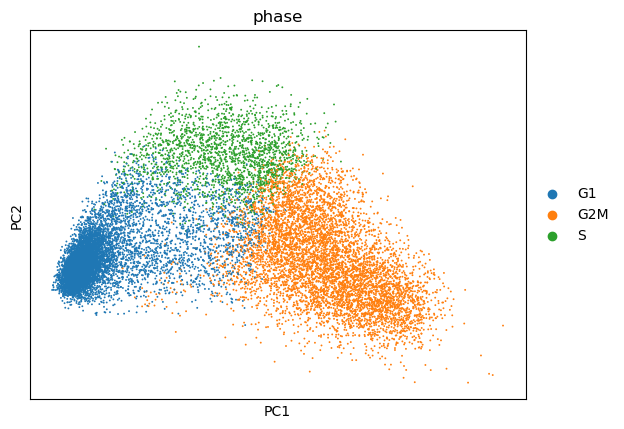

In [16]:
# regev_genes = [g for g in regev_genes if g in adata.var_names]

# adata_cc_genes = adata[:, regev_genes]
# sc.tl.pca(adata_cc_genes, mask_var=None)
# sc.pl.pca(adata_cc_genes, color='phase')

regressing out ['S_score', 'G2M_score']
    sparse input is densified and may lead to high memory use


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/scanpy/preprocessing/_simple.py:667: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/scanpy/preprocessing/_simple.py:667: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


    finished (0:00:05)
computing PCA
    with n_comps=50
    finished (0:00:00)


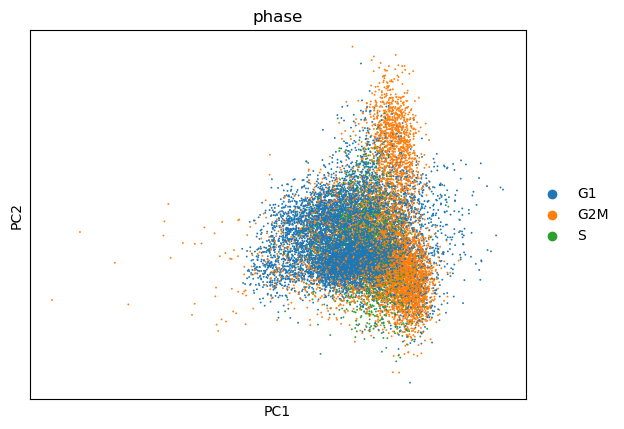

In [17]:
# sc.pp.regress_out(adata, ['S_score', 'G2M_score'])
# adata_cc_genes = adata[:, regev_genes]
# sc.tl.pca(adata_cc_genes)
# sc.pl.pca_scatter(adata_cc_genes, color='phase')

# Dimension reduction

In [10]:
gdf = adata.var[['gene_type']].copy()
gdf = gdf.reset_index(names='names')

protein_coding = gdf[gdf['gene_type'] == 'protein_coding']['names'].unique()
print(len(protein_coding))


adata.var['filter_pass'] = True # set the gene filter

# pt genes only
adata.var['filter_pass'] = np.where(~adata.var.index.isin(protein_coding), False, adata.var['filter_pass'])

# disallow GO cell cycle genes
fpath = "../../resources/human_cell_cycle_genes.csv"
cdf = pd.read_csv(fpath)
adata.var['filter_pass'] = np.where(adata.var.index.isin(cdf['gene_name'].unique()), False, adata.var['filter_pass'])

# disallow Regev cell cycle genes
fpath = "../../resources/regev_lab_cell_cycle_genes.txt"
genes = [x.strip() for x in open(fpath)]
adata.var['filter_pass'] = np.where(adata.var.index.isin(genes), False, adata.var['filter_pass'])

# disallow mitochondrial and ribosomal genes
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('MT'), False, adata.var['filter_pass'])
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('RP'), False, adata.var['filter_pass'])

print(adata.var['filter_pass'].value_counts().to_string())

15822
filter_pass
True     15393
False     9733


extracting highly variable genes
Number of HVG: 3000


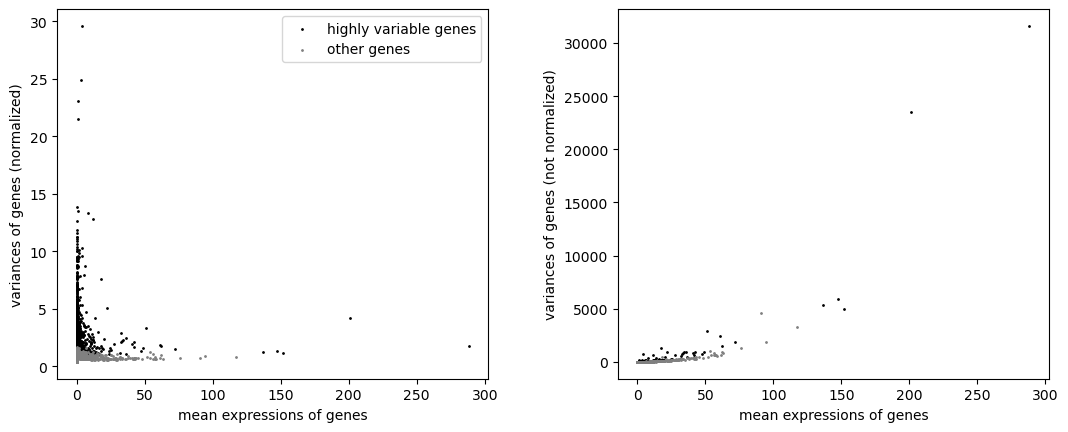

computing PCA
    with n_comps=50
    finished (0:00:04)


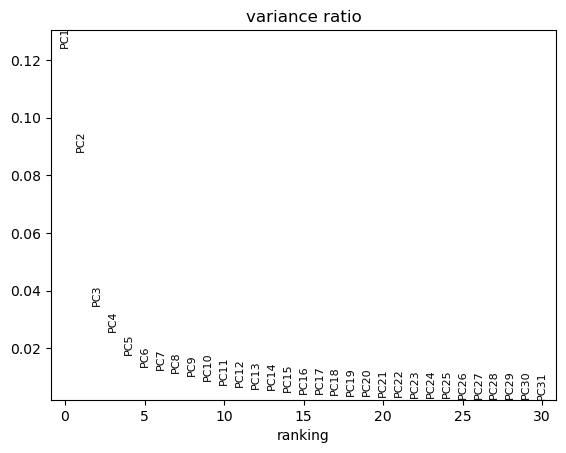

... storing 'assigned_condition' as categorical
... storing 'dataset' as categorical
... storing 'pooled_condition' as categorical
... storing 'phase' as categorical


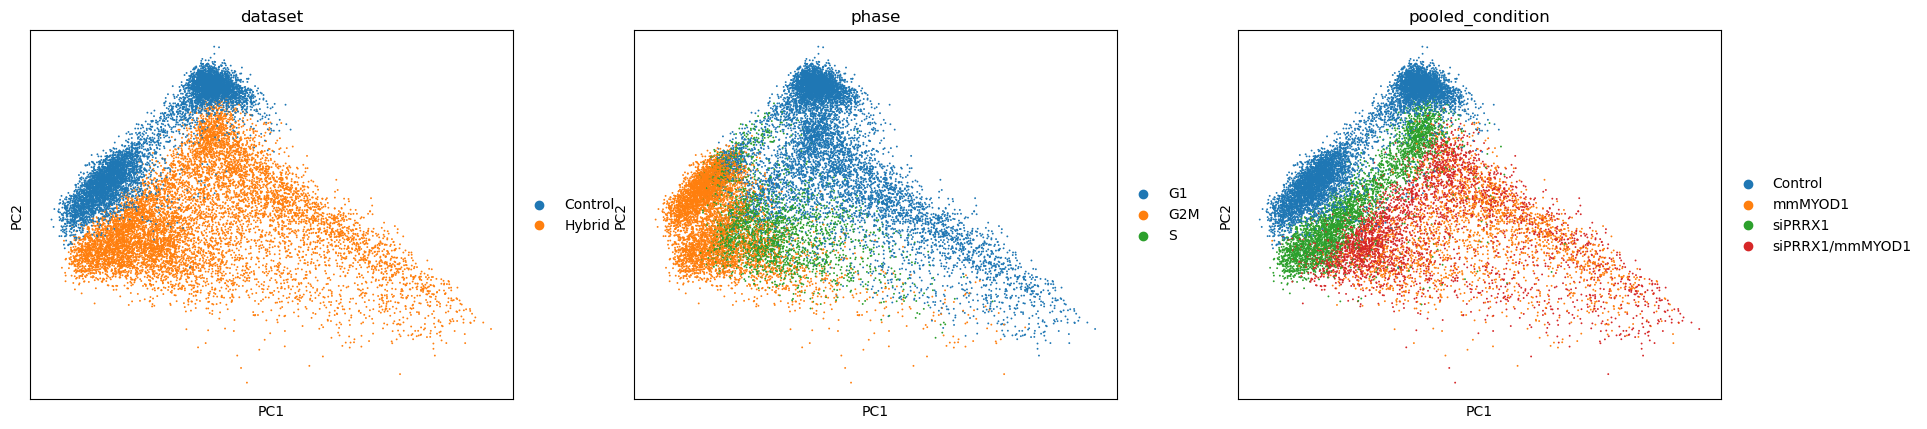

AnnData object with n_obs × n_vars = 16367 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std', 'filter_pass', 'highly_variable', 'hi

In [11]:
### HVGs
adata.X = adata.layers['raw_counts'].copy()

# automatically scales the data
sc.pp.highly_variable_genes(
    adata,
    flavor='seurat_v3',
    n_top_genes=3000,
    batch_key='dataset',
)

print(f"Number of HVG: {adata.var['highly_variable'].sum()}")

plt.rcdefaults()
sc.pl.highly_variable_genes(adata)


# # remove cell cycle genes from HVGs
# adata.var['highly_variable_no_cc'] = (
#     adata.var['highly_variable'] & ~adata.var_names.isin(regev_genes)
# )
# print(f"Number of HVGs w/o cc_genes: {adata.var['highly_variable_no_cc'].sum()}")


adata.X = adata.layers['log_norm'].copy()

### PCA with 'filter_pass' genes
sc.pp.pca(
    adata,
    # mask_var='highly_variable_no_cc',
    # mask_var='filter_pass',
)

sc.pl.pca_variance_ratio(adata)
sc.pl.pca(
    adata, 
    color=['dataset', 'phase', 'pooled_condition'],
    # annotate_var_explained=True,
    ncols=3,
)

adata

# Harmony integration

2026-05-11 13:37:34,291 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-11 13:37:34 | [INFO] Computing initial centroids with sklearn.KMeans...
2026-05-11 13:37:38,002 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-05-11 13:37:38 | [INFO] sklearn.KMeans initialization complete.
2026-05-11 13:37:38,054 - harmonypy - INFO - Iteration 1 of 10
2026-05-11 13:37:38 | [INFO] Iteration 1 of 10
2026-05-11 13:37:41,398 - harmonypy - INFO - Iteration 2 of 10
2026-05-11 13:37:41 | [INFO] Iteration 2 of 10
2026-05-11 13:37:44,701 - harmonypy - INFO - Converged after 2 iterations
2026-05-11 13:37:44 | [INFO] Converged after 2 iterations


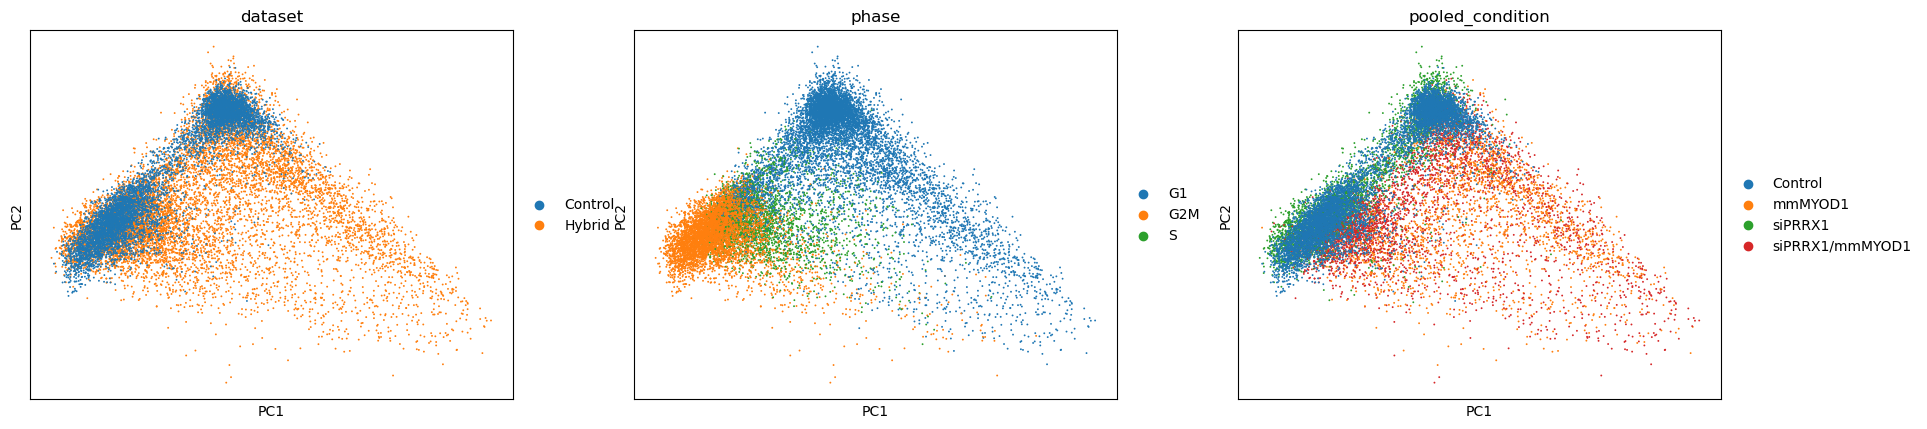

In [12]:
bdata = adata.copy()

### Harmony integration
sce.pp.harmony_integrate(bdata, key=['dataset'])#, 'phase'])
# sce.pp.harmony_integrate(bdata, key=['phase', 'dataset'])

# Save original PCA space
bdata.obsm["X_pca_original"] = bdata.obsm["X_pca"].copy()

# Set Harmony-corrected PCA as the default for plotting
bdata.obsm["X_pca"] = bdata.obsm["X_pca_harmony"].copy()

# sc.pl.pca(bdata, color='dataset')
sc.pl.pca(
    bdata, 
    color=['dataset', 'phase', 'pooled_condition'],
    # annotate_var_explained=True,
    ncols=3,
)

# Neighbors and UMAP

In [13]:
# remove doublets (they do not form their own cluster)

df = bdata.obs[['pooled_condition', 'doublet_score', 'predicted_doublet']].copy()
display(df.head())

display(df.groupby('pooled_condition', observed=True)['doublet_score'].describe())

df.groupby('pooled_condition', observed=True)['predicted_doublet'].value_counts()

,pooled_condition,doublet_score,predicted_doublet
AAACCAAAGCAACTGC_hybrid,siPRRX1/mmMYOD1,0.029301,False
AAACCAAAGTAGGGCA_hybrid,mmMYOD1,0.186876,False
AAACCAAAGTCTAGGC_hybrid,siPRRX1/mmMYOD1,0.166452,False
AAACCATTCACGTAAT_hybrid,siPRRX1,0.010171,False
AAACCATTCAGGCAGA_hybrid,siPRRX1,0.015656,False


,count,mean,std,min,25%,50%,75%,max
pooled_condition,,,,,,,,
Control,6960.0,0.088600,0.061170,0.006347,0.051130,0.076078,0.107252,0.623762
mmMYOD1,2256.0,0.075400,0.048566,0.005408,0.044139,0.063139,0.092357,0.482993
siPRRX1,3689.0,0.051457,0.055997,0.003687,0.019053,0.033508,0.059298,0.556420
siPRRX1/mmMYOD1,3462.0,0.080439,0.059087,0.004647,0.042910,0.063139,0.099831,0.654545


pooled_condition  predicted_doublet
Control           False                6902
                  True                   58
mmMYOD1           False                2256
siPRRX1           False                3689
siPRRX1/mmMYOD1   False                3461
                  True                    1
Name: count, dtype: int64

In [14]:
# remove doublets
doublets = bdata.obs['predicted_doublet']

print(doublets.value_counts())

bdata = bdata[~doublets].copy()
bdata

predicted_doublet
False    16308
True        59
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 16308 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std', 'filter_pass', 'highly_variable', 'hi

running Leiden clustering
    finished (0:00:00)


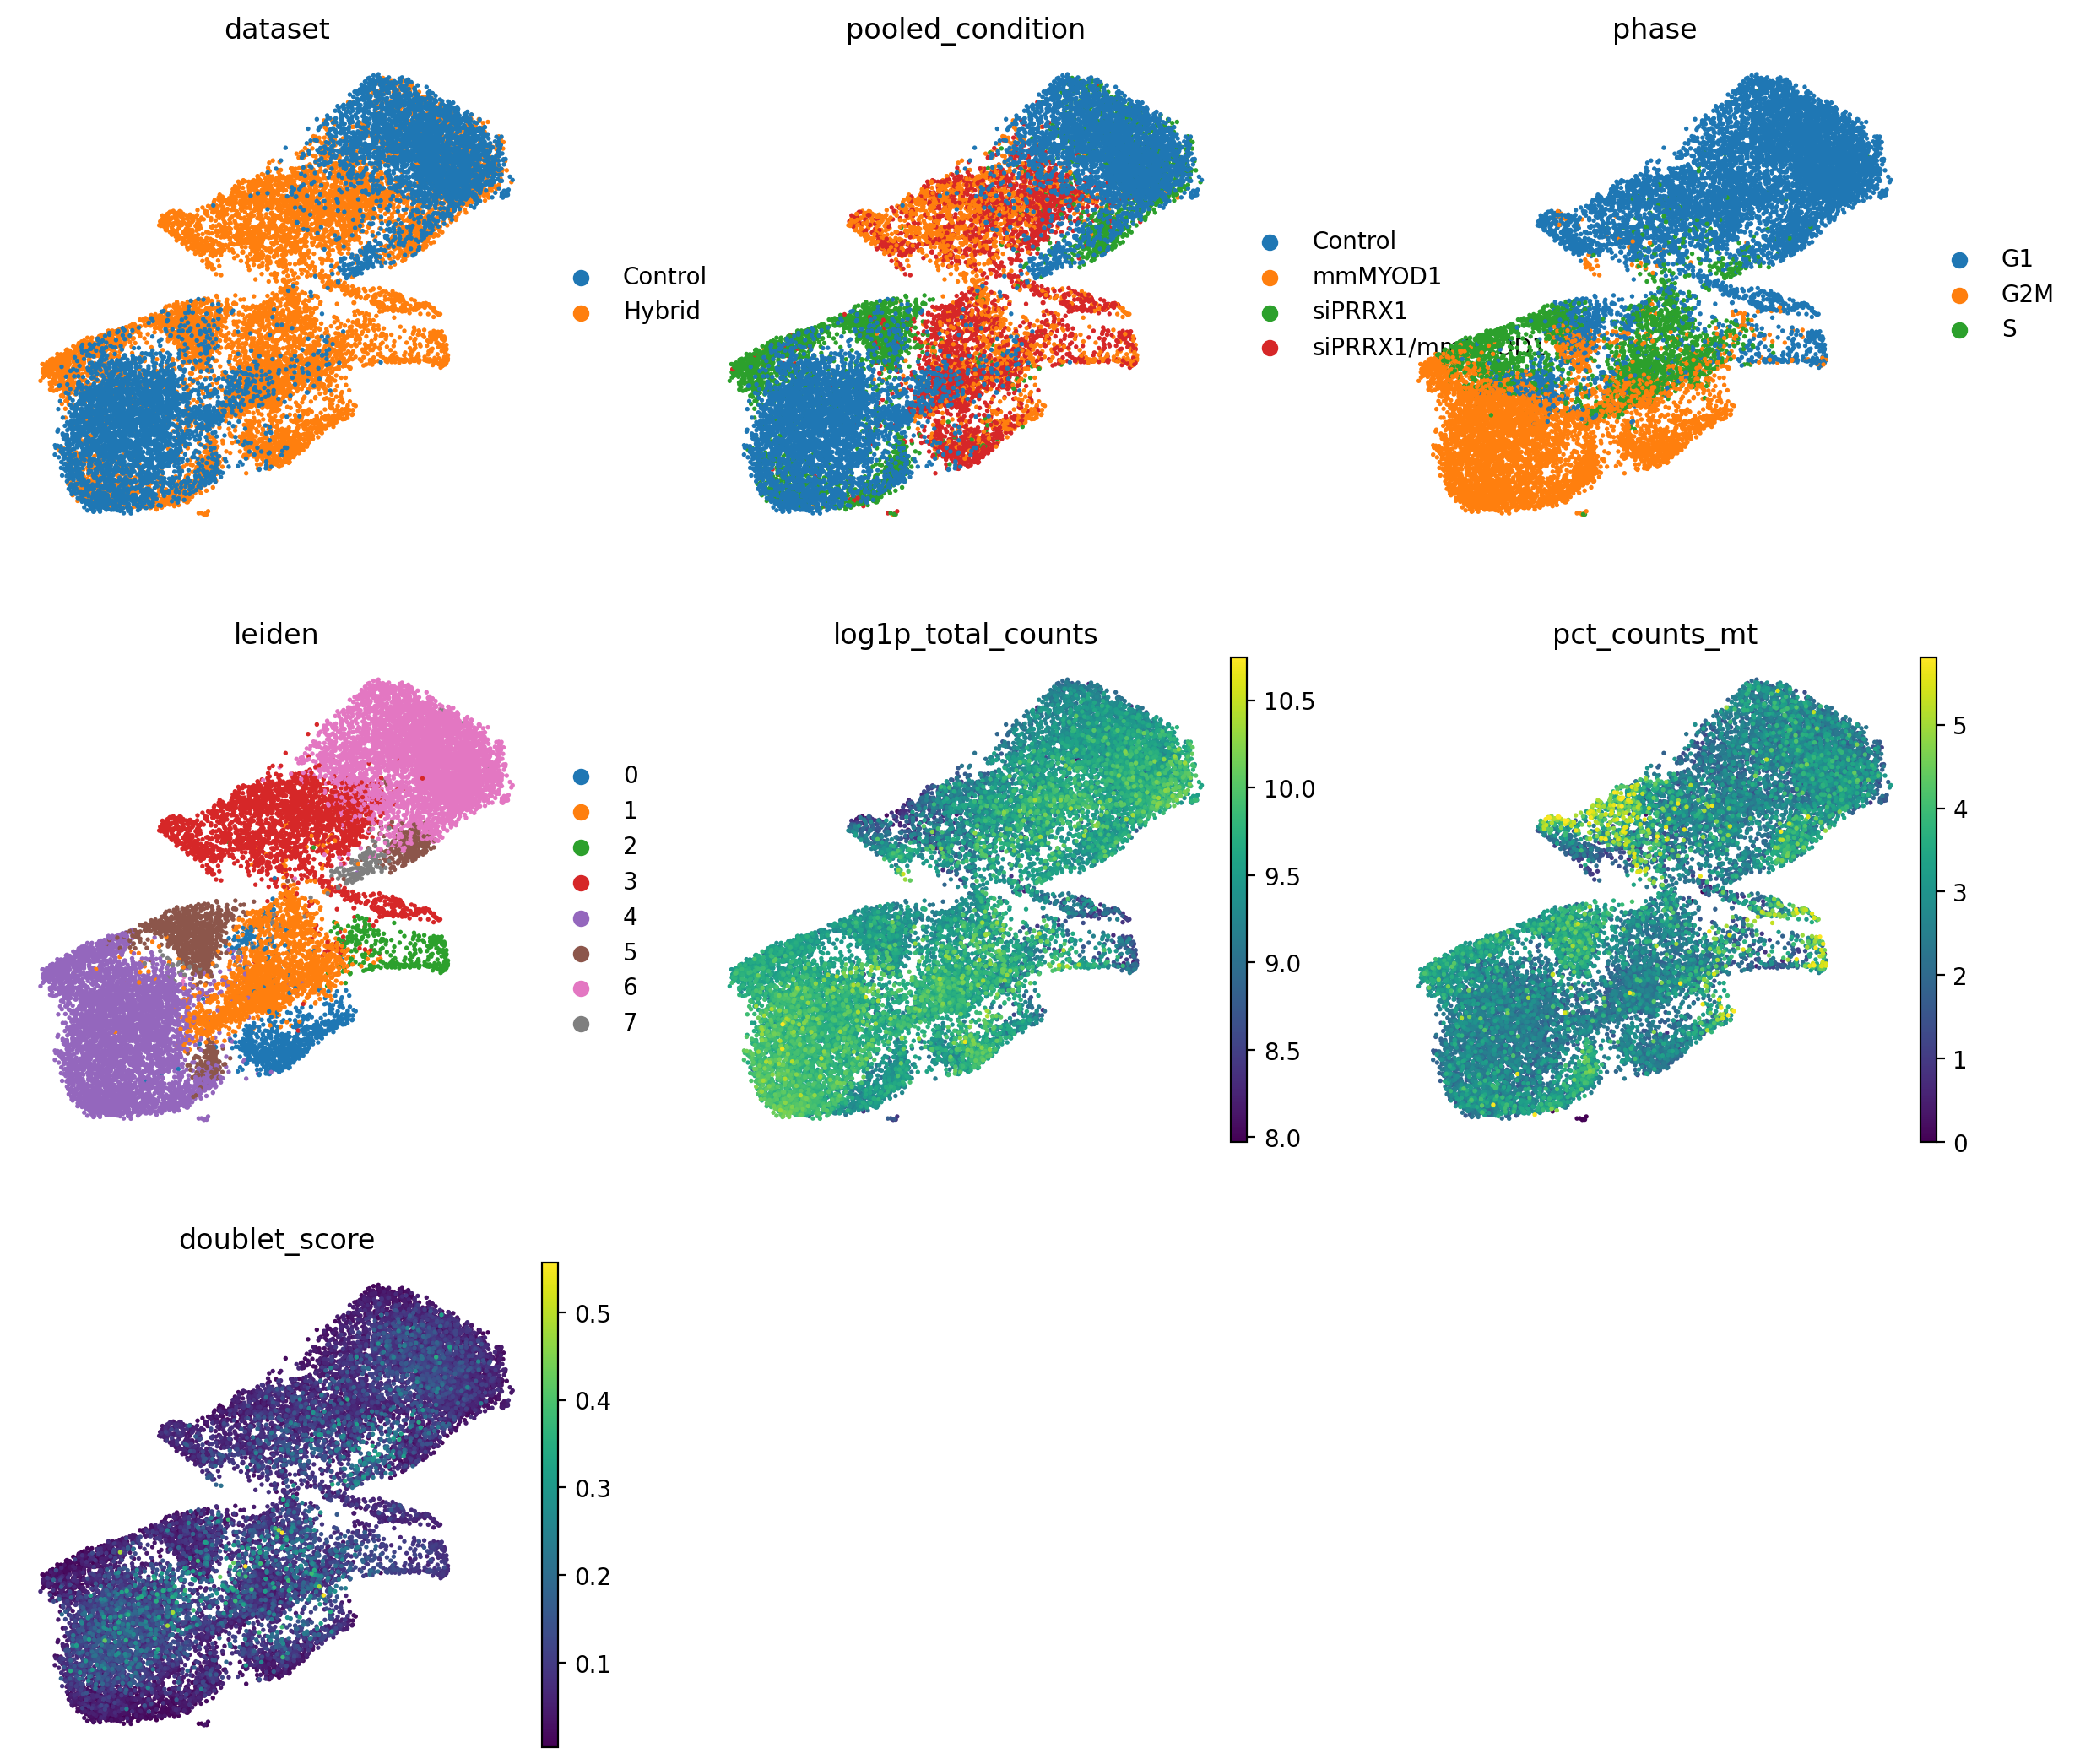

In [15]:
rsc.get.anndata_to_GPU(bdata)

rsc.pp.neighbors(
    bdata,
    use_rep='X_pca_harmony',
    n_neighbors=10, # 5 for OG, 10 for new  # 10
)

rsc.tl.umap(
    bdata,
    min_dist=0.4, # 0.4 for OG, 0.2 for new # 0.4
    spread=1.2, # 1.2
)

rsc.get.anndata_to_CPU(bdata)

sc.tl.leiden(
    bdata,
    resolution=0.5,
    flavor='igraph',
)

plt.rcdefaults()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    bdata,
    color=['dataset', 'pooled_condition', 'phase', 'leiden', 'log1p_total_counts', 'pct_counts_mt', 'doublet_score',],
    size=15,
    ncols=3,
    # add_outline=True,
    # outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

In [115]:
bdata.obs['cluster_str'] = bdata.obs['leiden'].apply(lambda x: f"C{str(int(x) + 1)}")

bdata.obs['cluster_str'].value_counts()

cluster_str
C3    5403
C5    4391
C1    4287
C2    1767
C4     448
C6      12
Name: count, dtype: int64

In [116]:
clusters_to_remove = ['C6']

bdata = bdata[~bdata.obs['cluster_str'].isin(clusters_to_remove)]

print(bdata.obs['cluster_str'].value_counts())

cluster_str
C3    5403
C5    4391
C1    4287
C2    1767
C4     448
Name: count, dtype: int64


# Sub-cluster per condition

computing neighbors
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
computing neighbors
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
computing neighbors
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
computing neighbors
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)


... storing 'leiden_split' as categorical


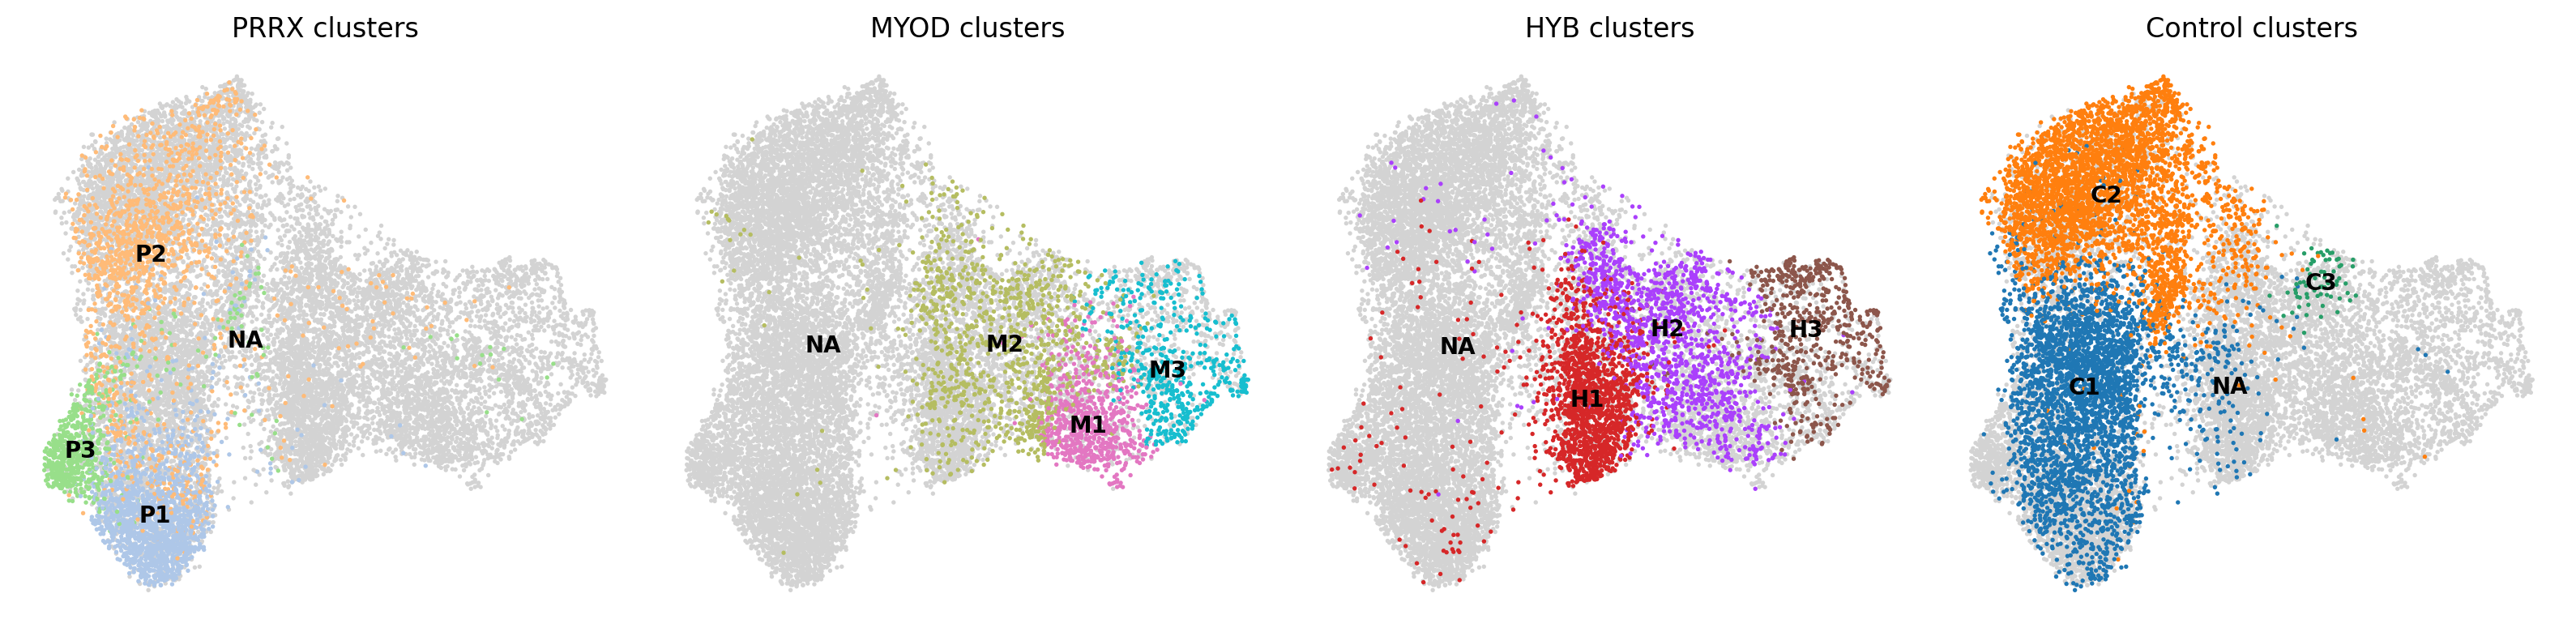

In [117]:
## OG
# myod_res = 0.25
# prrx_res = 0.25
# hyb_res = 0.25
# ctrl_res = 0.2

myod_res = 0.25
prrx_res = 0.25
hyb_res = 0.25
ctrl_res = 0.25

# Cluster mmMYOD1 cells separately from controls
subset_myod = bdata[bdata.obs['pooled_condition'] == 'mmMYOD1'].copy()
sc.pp.neighbors(subset_myod, n_neighbors=10, use_rep='X_pca_harmony')
sc.tl.leiden(subset_myod, resolution=myod_res, flavor='igraph')

subset_hyb = bdata[bdata.obs['pooled_condition'] == 'siPRRX1/mmMYOD1'].copy()
sc.pp.neighbors(subset_hyb, n_neighbors=10, use_rep='X_pca_harmony')
sc.tl.leiden(subset_hyb, resolution=hyb_res, flavor='igraph')

subset_prrx = bdata[bdata.obs['pooled_condition'] == 'siPRRX1'].copy()
sc.pp.neighbors(subset_prrx, n_neighbors=10, use_rep='X_pca_harmony')
sc.tl.leiden(subset_prrx, resolution=prrx_res, flavor='igraph')


subset_ctrl = bdata[bdata.obs['pooled_condition'] == 'Control'].copy()
sc.pp.neighbors(subset_ctrl, n_neighbors=10, use_rep='X_pca_harmony')
sc.tl.leiden(subset_ctrl, resolution=ctrl_res, flavor='igraph')



# Add back to adata as one group
bdata.obs['leiden_split'] = None
bdata.obs.loc[subset_myod.obs_names, 'leiden_split'] = ('M' + (subset_myod.obs['leiden'].astype(int) + 1).astype(str))
bdata.obs.loc[subset_hyb.obs_names, 'leiden_split'] = ('H' + (subset_hyb.obs['leiden'].astype(int) + 1).astype(str))
bdata.obs.loc[subset_prrx.obs_names, 'leiden_split'] = ('P' + (subset_prrx.obs['leiden'].astype(int) + 1).astype(str))
bdata.obs.loc[subset_ctrl.obs_names, 'leiden_split'] = ('C' + (subset_ctrl.obs['leiden'].astype(int) + 1).astype(str))


# plotting 
mask_prrx = bdata.obs['leiden_split'].str.startswith('P')
mask_myod = bdata.obs['leiden_split'].str.startswith('M')
mask_hyb = bdata.obs['leiden_split'].str.startswith('H')
mask_ctrl = bdata.obs['leiden_split'].str.startswith('C')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sc.pl.umap(
    bdata,
    color='leiden_split',
    mask_obs=mask_prrx,
    size=15,
    frameon=False,
    alpha=1,
    ax=axes[0],
    show=False,
    title="PRRX clusters",
    legend_loc='on data',
)

sc.pl.umap(
    bdata,
    color='leiden_split',
    mask_obs=mask_myod,
    size=15,
    frameon=False,
    alpha=1,
    ax=axes[1],
    show=False,
    title="MYOD clusters",
    legend_loc='on data',
)

sc.pl.umap(
    bdata,
    color='leiden_split',
    mask_obs=mask_hyb,
    size=15,
    frameon=False,
    alpha=1,
    ax=axes[2],
    show=False,
    title="HYB clusters",
    legend_loc='on data',
)

sc.pl.umap(
    bdata,
    color='leiden_split',
    mask_obs=mask_ctrl,
    size=15,
    frameon=False,
    alpha=1,
    ax=axes[3],
    show=False,
    title="Control clusters",
    legend_loc='on data',
)

plt.tight_layout()
plt.show()

In [118]:
bdata.obs['leiden_split'].value_counts()

leiden_split
C2    3576
C1    3260
P1    1560
H1    1559
P2    1438
H2    1337
M2    1078
M1     691
P3     685
H3     560
M3     486
C3      66
Name: count, dtype: int64

['#393b79',
 '#5254a3',
 '#9c9ede',
 '#8ca252',
 '#cedb9c',
 '#bd9e39',
 '#e7ba52',
 '#843c39',
 '#d6616b',
 '#7b4173',
 '#ce6dbd',
 '#de9ed6']

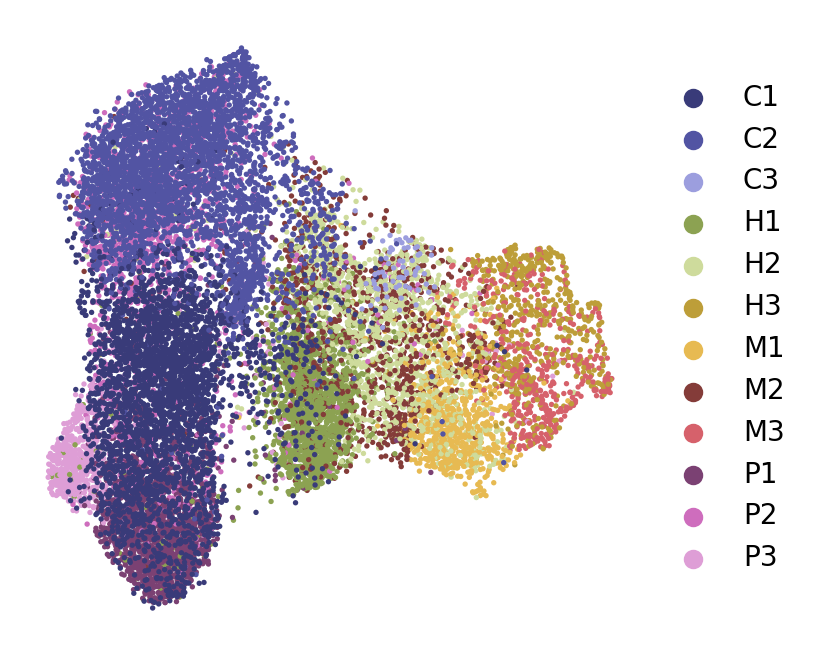

In [119]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    bdata,
    color='leiden_split',
    size=15,
    frameon=False,
    alpha=1,
    palette='tab20b',
    show=False,
    title='',
    # legend_loc='on data',
)

bdata.uns['leiden_split_colors'] = sc.pl.palettes.default_20 if 'leiden_split_colors' not in bdata.uns else bdata.uns['leiden_split_colors']
bdata.uns['leiden_split_colors'] 

/tmp/ipykernel_1735370/364432014.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  bdata.obs['leiden_split'] = bdata.obs['leiden_split'].replace({'H3': 'TEMP_SWAP', 'H2': 'H3'})
/tmp/ipykernel_1735370/364432014.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  bdata.obs['leiden_split'] = bdata.obs['leiden_split'].replace('TEMP_SWAP', 'H2')
/tmp/ipykernel_1735370/364432014.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the cat

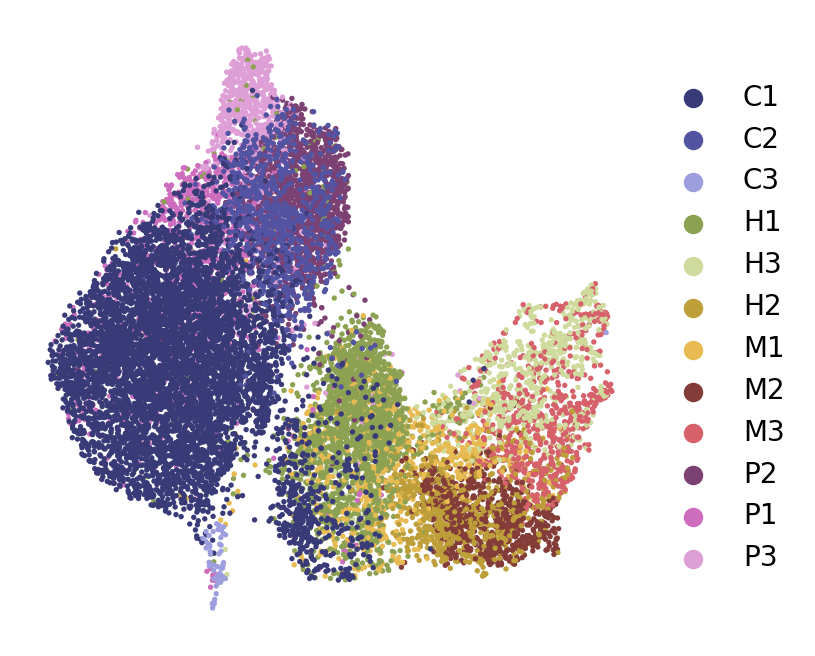

In [28]:
# bdata.obs['leiden_split'] = bdata.obs['leiden_split'].replace({'H3': 'TEMP_SWAP', 'H2': 'H3'})
# bdata.obs['leiden_split'] = bdata.obs['leiden_split'].replace('TEMP_SWAP', 'H2')

# bdata.obs['leiden_split'] = bdata.obs['leiden_split'].replace({'P1': 'TEMP_SWAP', 'P2': 'P1'})
# bdata.obs['leiden_split'] = bdata.obs['leiden_split'].replace('TEMP_SWAP', 'P2')

# sc.pl.umap(
#     bdata,
#     color='leiden_split',
#     size=15,
#     frameon=False,
#     alpha=1,
#     title='',
# )

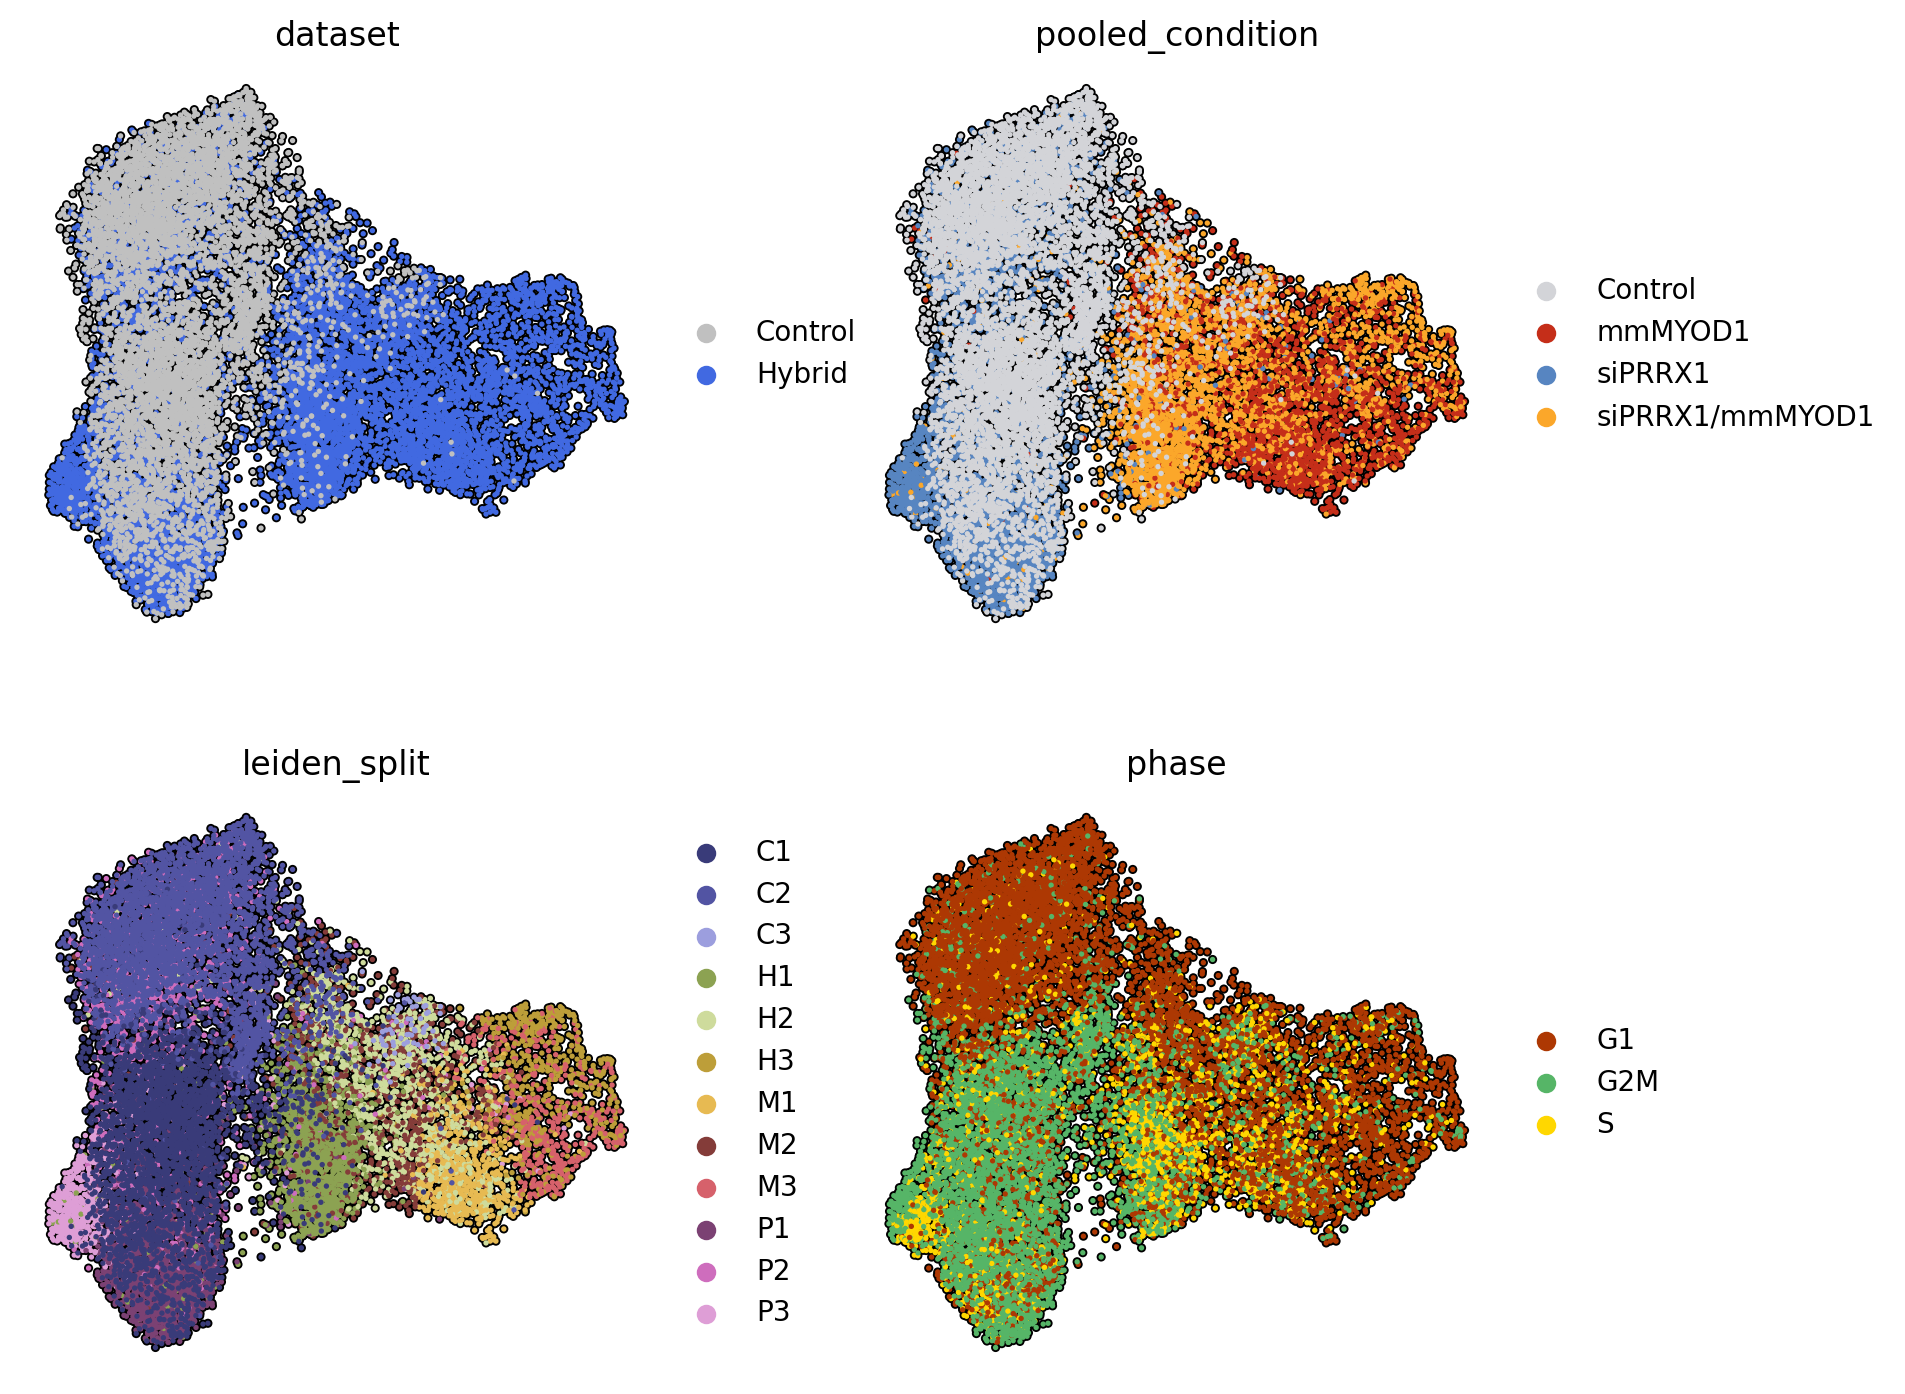

In [120]:
# cluster_colors = [
#     "#E2514A",
#     "#FCA55D",
#     "#FEE99B",
#     "#439BB5",
#     "#90D2A4",
#     # "#439BB5",
# ]
# bdata.uns['cluster_str_colors'] = cluster_colors

colors = {
    'Control': '#D3D4D8',
    'mmMYOD1': '#C52E19',
    'siPRRX1/mmMYOD1': '#FBA72A',
    'siPRRX1': '#5785C1'
}


bdata.uns['dataset_colors'] = ["silver", "royalblue"]

phase_colors = ['#ad3803', '#56b567', 'gold']
bdata.uns['phase_colors'] = phase_colors

# condition_colors = ['silver', "#F5A35B", "#9B5CA6", "#9ECAE1"]
condition_colors = ['#D3D4D8', '#C52E19', '#5785C1', '#FBA72A']
bdata.uns['pooled_condition_colors'] = condition_colors

sc.pl.umap(
    bdata,
    color=['dataset', 'pooled_condition', 'leiden_split', 'phase'],
    size=15,
    ncols=2,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

In [32]:
# bdata.write("/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad")
# bdata

AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'm

In [121]:
bdata.write("/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad")
bdata

AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st